<h3>Análisis exploratorio de los datos.</h3>

In [279]:
load('.RData')
options(warn=-1) ## SUPRIMIDOS WARGNING GOBALMENTE  ---> activar ->options(warn=0) 

In [280]:
library(ggplot2)
library(tidyverse)
library(ggpubr)

In [281]:
penguins_color = c("#FFA347","#CF74D2","#139FA4") #Adelie, Chinstrap, Gentoo
sex_color = c('#D35F4A', '#00B88D', '#35415A') # female, male
island_color = c('#0077B6','#00B4D8','#90E0EF') # Biscoe, Dream, Torgersen

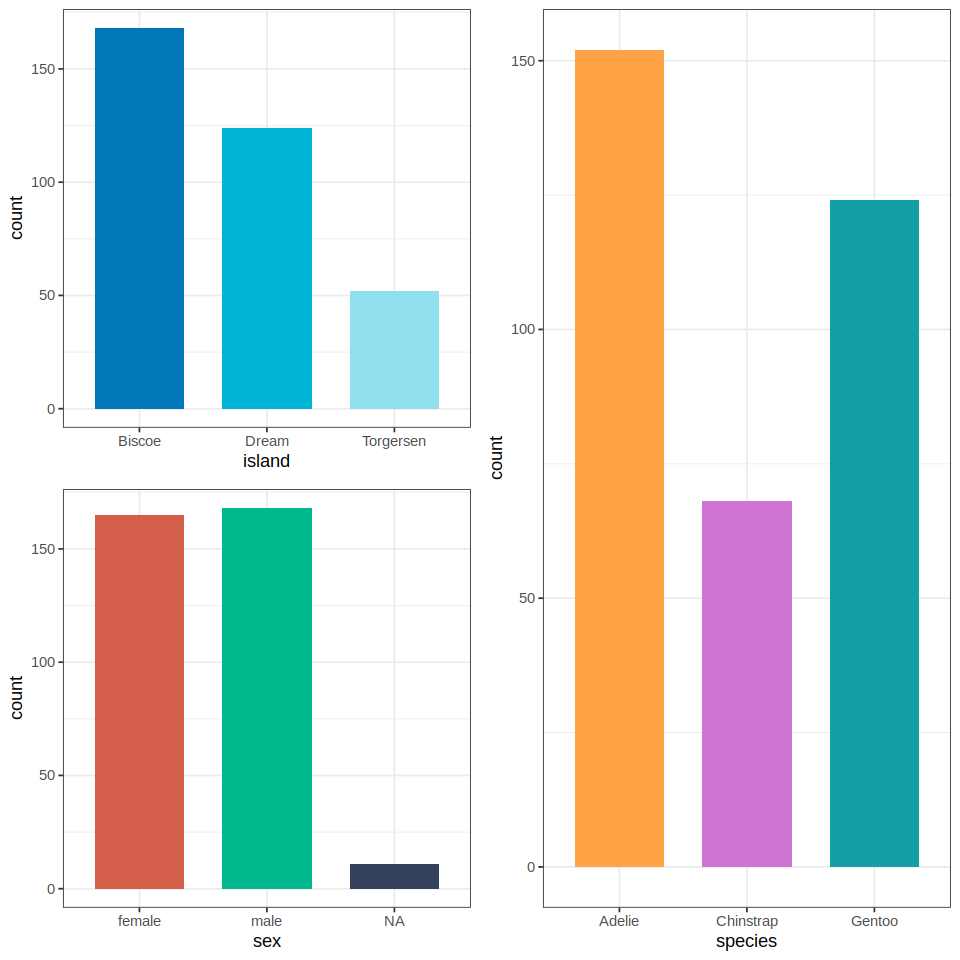

In [282]:
p1 <- ggplot(df_penguins, aes(x = species)) +
        geom_bar(stat="count", width=0.7, fill=penguins_color) +
        theme_bw()
p2 <- ggplot(df_penguins, aes(x = island)) +
        geom_bar(stat="count", width=0.7, fill = island_color) +
        theme_bw()
p3 <- ggplot(df_penguins, aes(x = sex)) +
        geom_bar(stat="count", width=0.7, fill = sex_color) +
        theme_bw()
options(repr.plot.width=8, repr.plot.height=8)
ggarrange(
        ggarrange(p2, p3, ncol = 1, nrow = 2), p1
    )

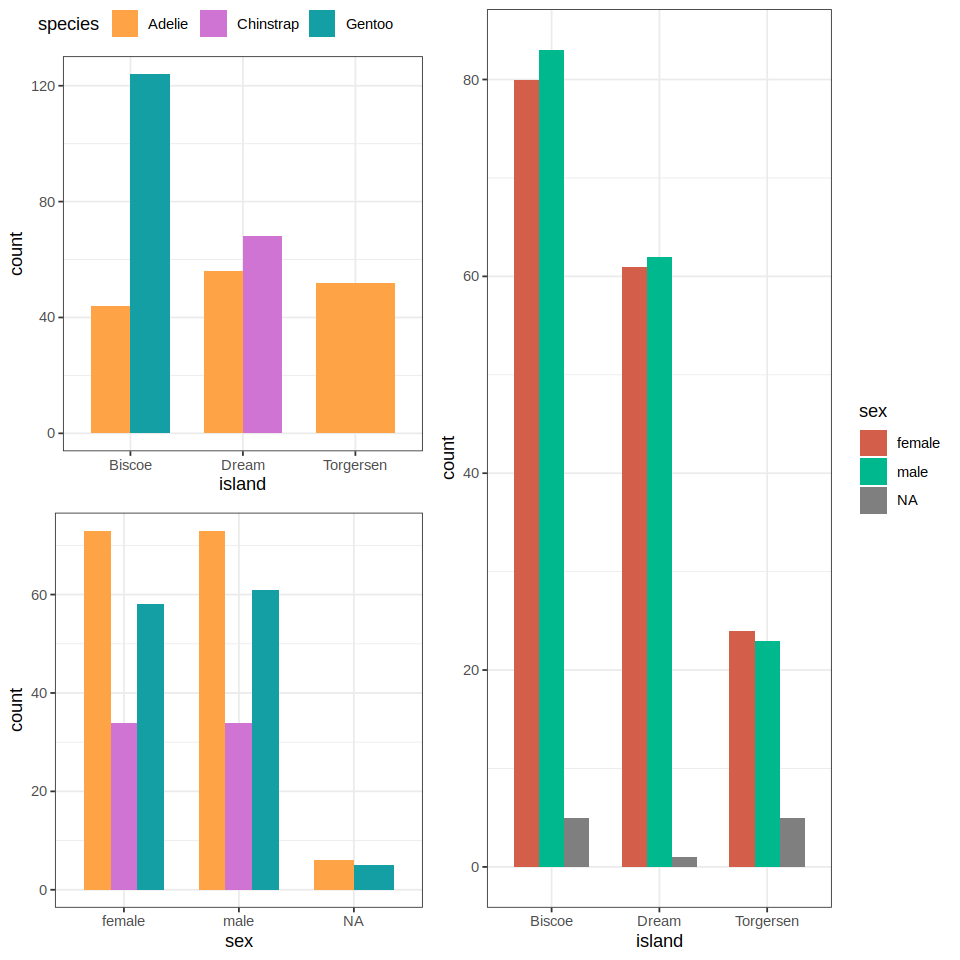

In [283]:
p1 <- ggplot(df_penguins, aes(island, fill = species)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = penguins_color)

p2 <- ggplot(df_penguins, aes(sex, fill = species)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = penguins_color)


p3 <- ggplot(df_penguins, aes(island, fill = sex)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = sex_color)
ggarrange(
        ggarrange(p1, p2, ncol = 1, nrow = 2, common.legend = TRUE, legend="top"),
        p3, ncol = 2, nrow = 1,
        widths = c(0.9,1.1)
    )


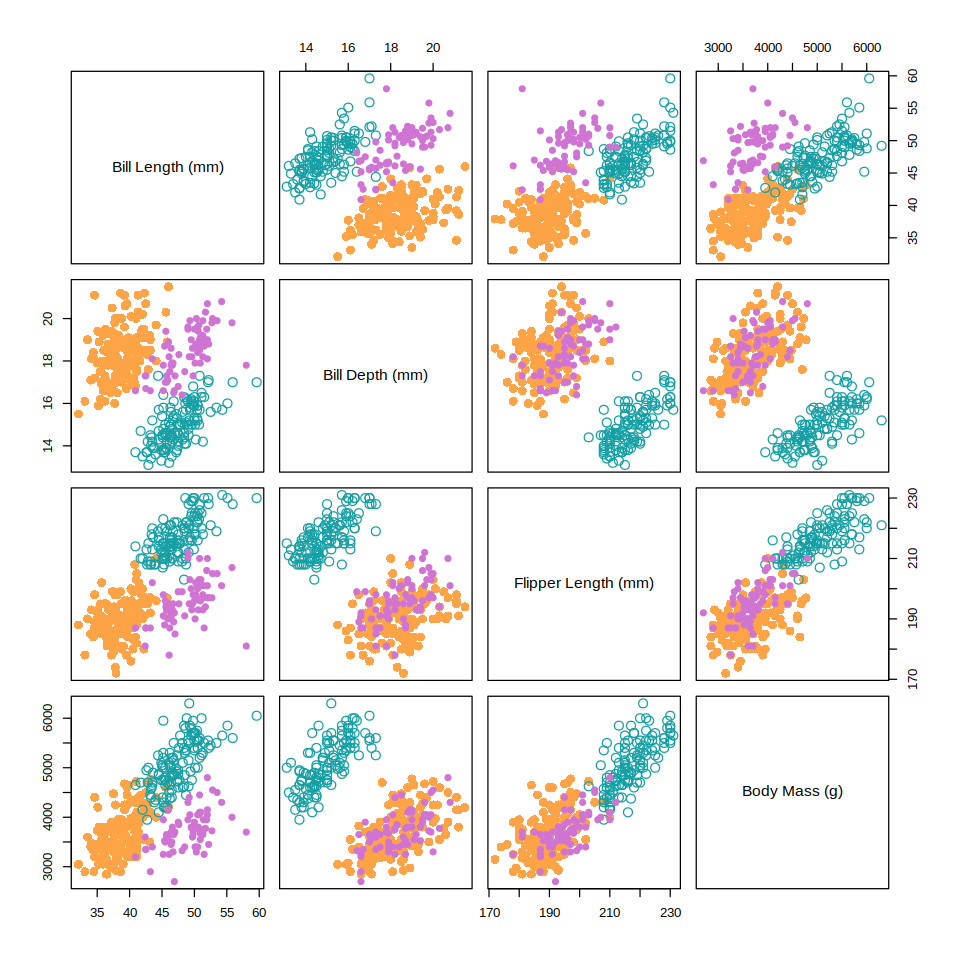

In [284]:
pairs(df_penguins[,3:6], 
      cex=1.5, 
      labels = c('Bill Length (mm)', 'Bill Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)'), 
      pch=c(16, 20, 21)[df_penguins$species], 
      col = penguins_color[df_penguins$species])

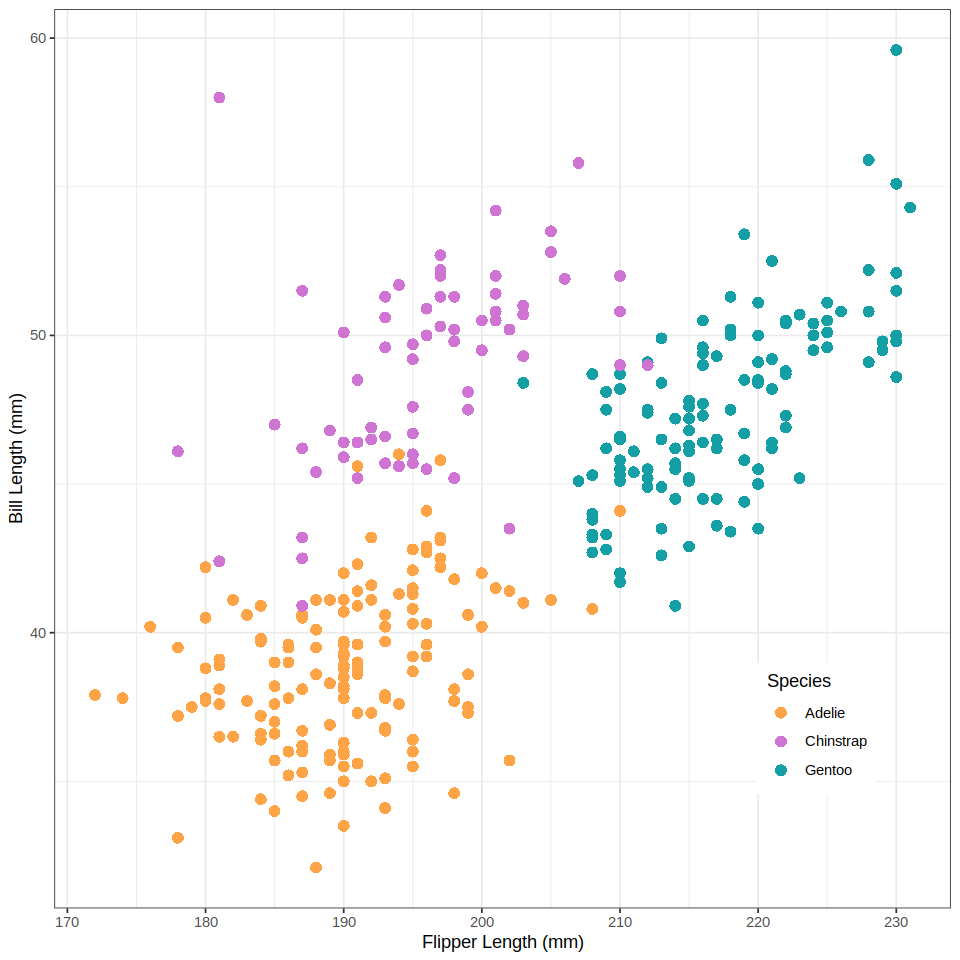

In [285]:
## BILL LENGTH vs FLIPPER LENGTH
bill_flipper <- ggplot(data = df_penguins, 
                       aes(x = flipper_length_mm, y = bill_length_mm)) +
                geom_point(aes(color = species, shape =species), 
                                size = 3, 
                                pch=16) + 
                scale_color_manual(values = penguins_color) +  
                labs(  x = "Flipper Length (mm)",
                       y = "Bill Length (mm)",
                       color = "Species",
                       shape = "Species") +
                theme_bw() +
                theme(legend.position = c(0.85, 0.2))
                

bill_flipper

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



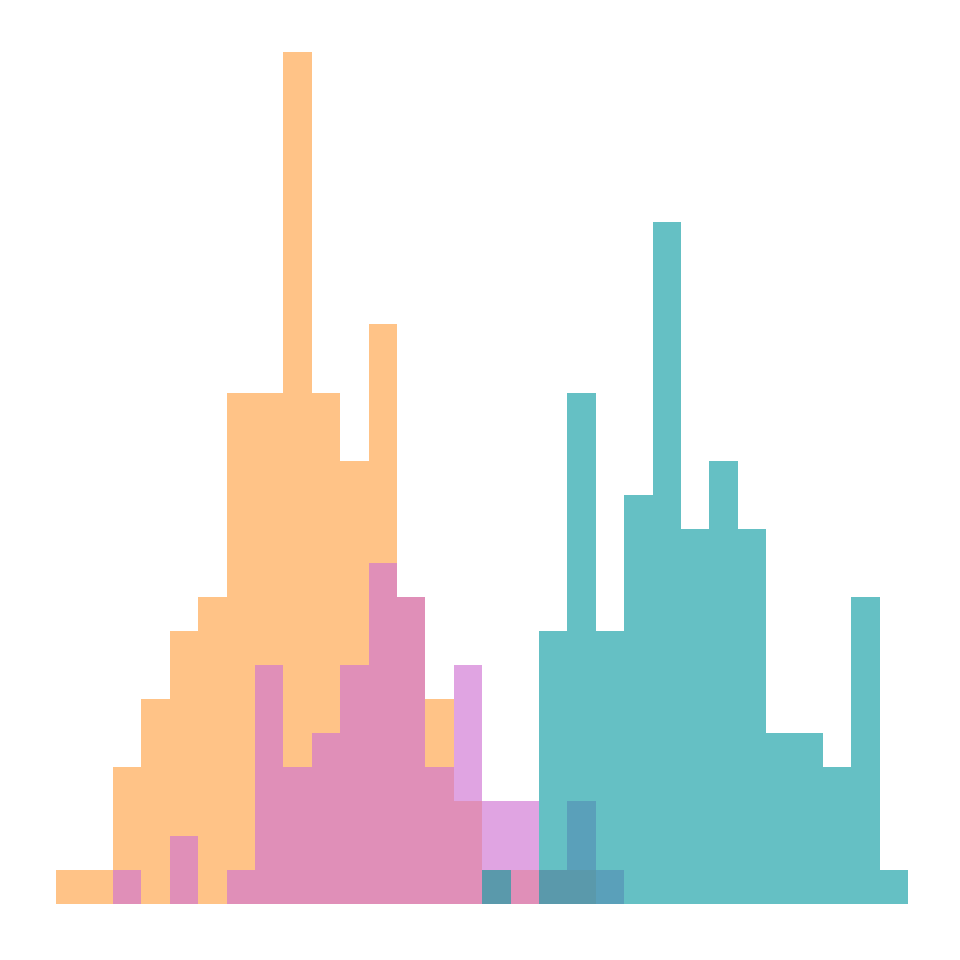

In [286]:
flipper_hist <- ggplot(data = df_penguins, aes(x = flipper_length_mm)) +
                  geom_histogram(aes(fill = species), 
                     alpha = 0.65, 
                     position = "identity") +
                  scale_fill_manual(values = penguins_color) +
                  labs(x = "",
                   y = "") +
                    theme_classic() + 
                    theme(axis.line=element_blank(),
                          axis.text.x=element_blank(),
                          axis.text.y=element_blank(),
                          axis.ticks=element_blank(),
                          axis.title.x=element_blank(),
                          axis.title.y=element_blank(),
                          legend.position="none",
                          panel.background=element_blank(),
                          panel.border=element_blank(),
                          panel.grid.major=element_blank(),
                          panel.grid.minor=element_blank(),
                          plot.background=element_blank())
flipper_hist

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



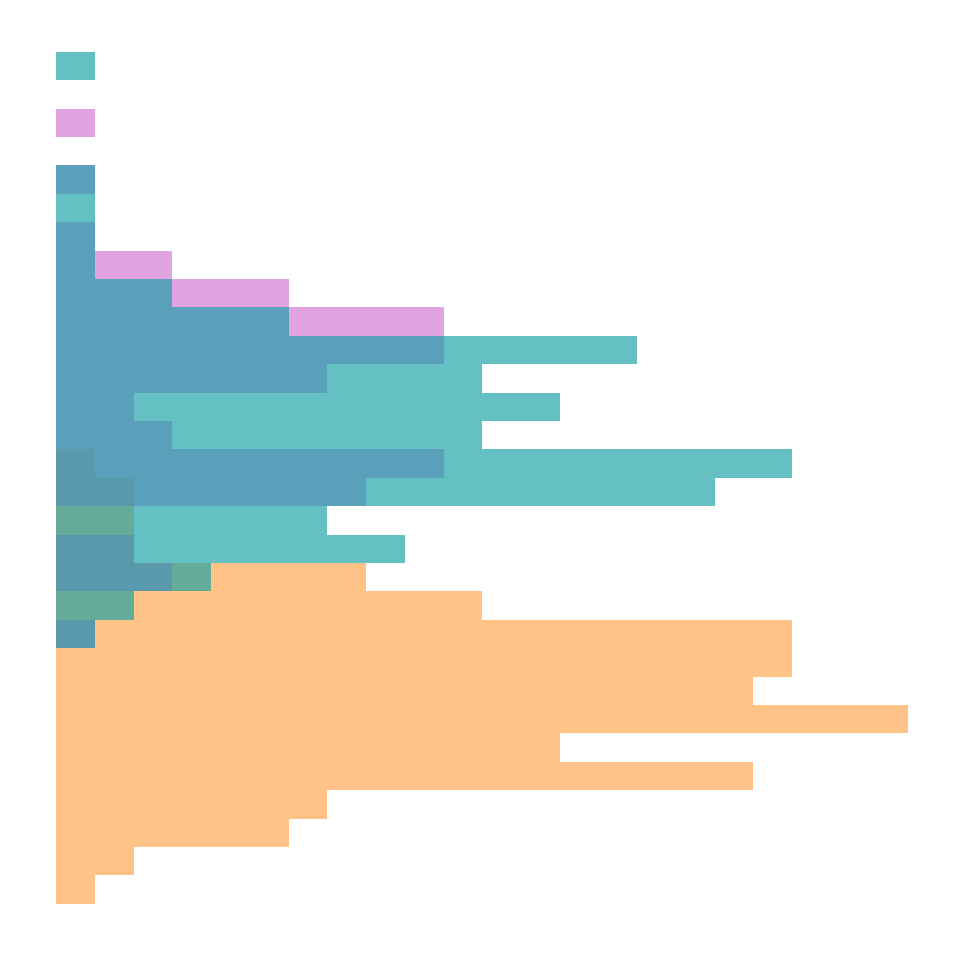

In [287]:
bill_hist <- ggplot(data = df_penguins, aes(x = bill_length_mm)) +
                  geom_histogram(aes(fill = species), 
                     alpha = 0.65, 
                     position = "identity") +
                  scale_fill_manual(values = penguins_color) +
                  labs(x = "",
                   y = "") +
                    theme_classic() + 
                    theme(axis.line=element_blank(),
                          axis.text.x=element_blank(),
                          axis.text.y=element_blank(),
                          axis.ticks=element_blank(),
                          axis.title.x=element_blank(),
                          axis.title.y=element_blank(),
                          legend.position="none",
                          panel.background=element_blank(),
                          panel.border=element_blank(),
                          panel.grid.major=element_blank(),
                          panel.grid.minor=element_blank(),
                          plot.background=element_blank()) +
                    coord_flip()
bill_hist

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



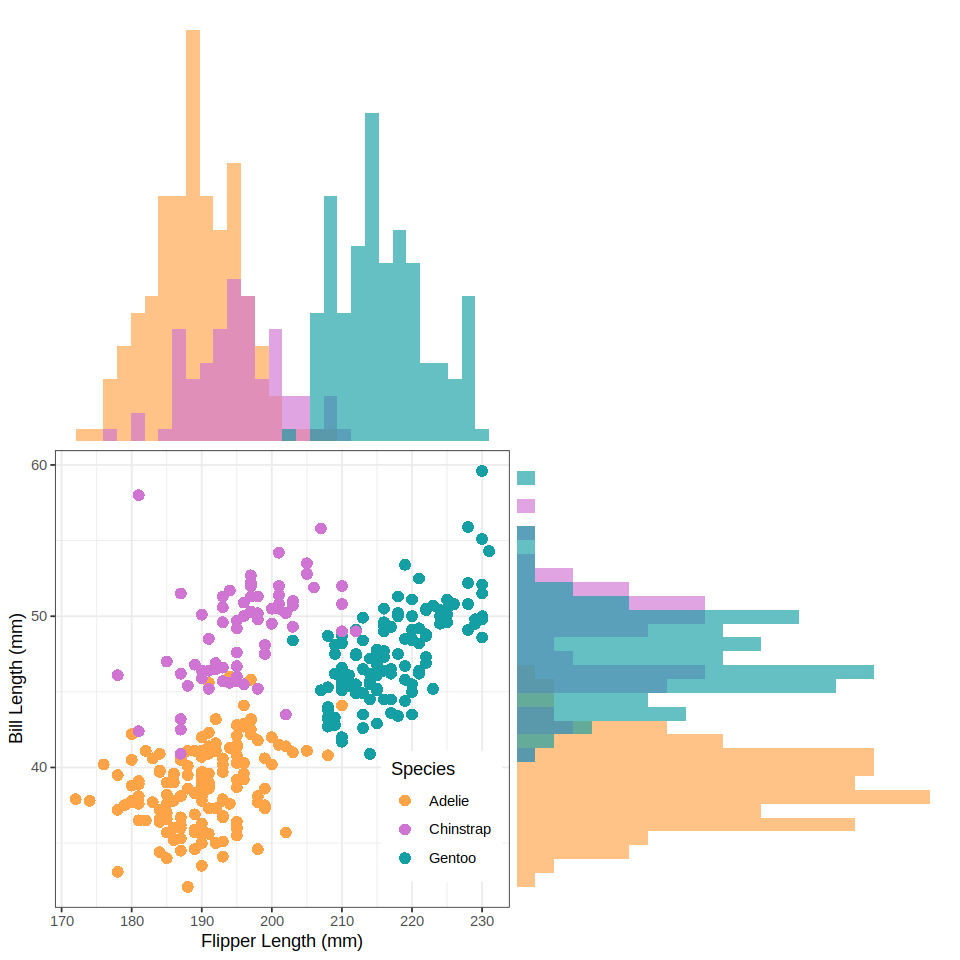

In [288]:
ggarrange(flipper_hist, 
          NULL, NULL,
          NULL, NULL, NULL, #FILA FANTASMA PARA LUEGO PODER ACERCAR LOS GRAFICOS
          bill_flipper, NULL,
          bill_hist,
          heights = c(1, -0.15, 1),
          widths = c(1, -0.15, 1),
          ncol = 3, nrow = 3, 
          align = 'hv')

<h4>Análisis de las variables con respecto a la especia</h4>

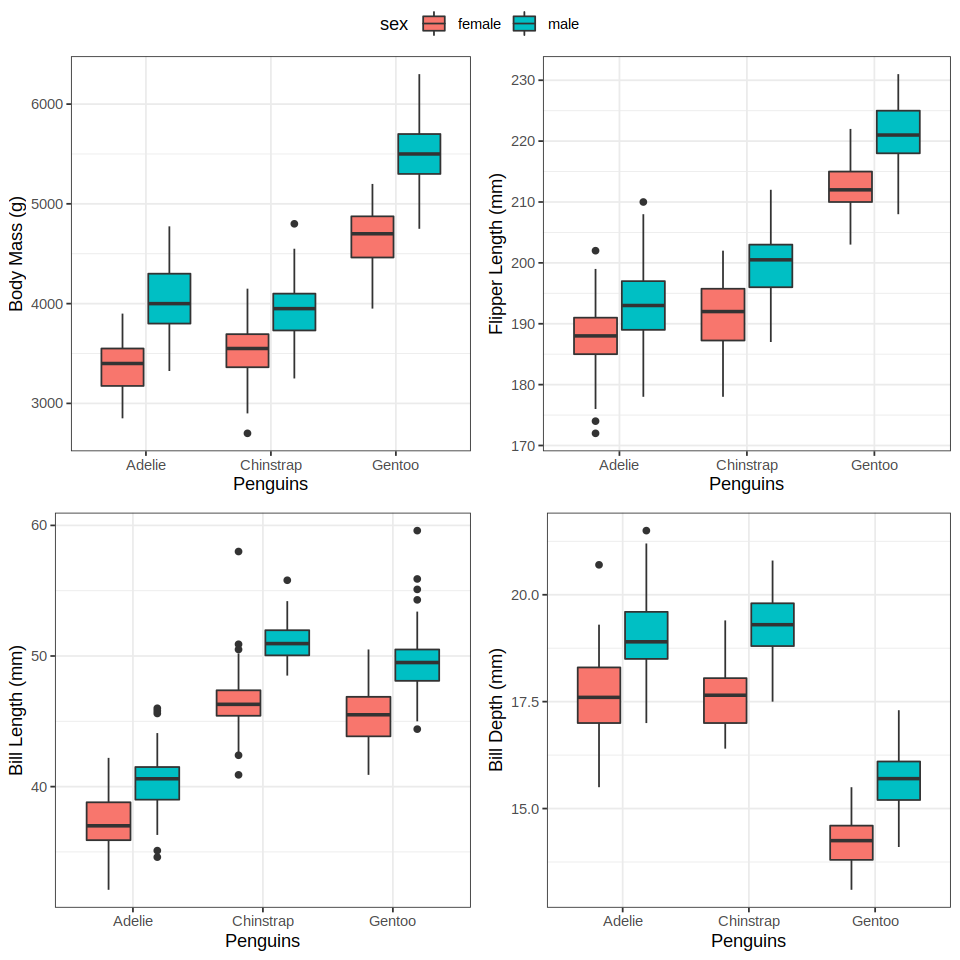

In [289]:
#Se omiten las filas con NA values
p1 <- ggplot(na.omit(df_penguins), aes(x = species, y = body_mass_g, fill = sex)) + 
        geom_boxplot() +
        #geom_jitter(size = 1, position=position_jitter(0.1)) +
        scale_color_manual(values= sex_color) +
        labs(x = 'Penguins', y = 'Body Mass (g)') +
        theme_bw() +
        theme(legend.position="bottom")
p2 <- ggplot(na.omit(df_penguins), aes(x = species, y = flipper_length_mm, fill = sex)) + 
        geom_boxplot() +
        scale_color_manual(values= sex_color) +
        labs(x = 'Penguins', y = 'Flipper Length (mm)') +
        theme_bw() +
        theme(legend.position="bottom")
p3 <- ggplot(na.omit(df_penguins), aes(x = species, y = bill_length_mm, fill = sex)) + 
        geom_boxplot() +
        scale_color_manual(values= sex_color) +
        labs(x = 'Penguins', y = 'Bill Length (mm)') +
        theme_bw() +
        theme(legend.position="bottom")
p4 <- ggplot(na.omit(df_penguins), aes(x = species, y = bill_depth_mm, fill = sex)) + 
        geom_boxplot() +
        scale_color_manual(values= sex_color) +
        labs(x = 'Penguins', y = 'Bill Depth (mm)') +
        theme_bw() +
        theme(legend.position="bottom")

ggarrange(p1, p2, p3, p4, 
          ncol = 2, nrow = 2, common.legend = TRUE, legend="top")

In [266]:
save.image()